<a href="https://colab.research.google.com/github/wajiha577/Assignment-1/blob/main/shuffle_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score



In [ ]:
BASE_PATH = "/content/drive/MyDrive/Dataset"
MRI_PATH  = os.path.join(BASE_PATH, "Brain Tumor MRI images")


In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 16
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    MRI_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    MRI_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)


Found 5000 files belonging to 2 classes.
Using 3500 files for training.
Found 5000 files belonging to 2 classes.
Using 1500 files for validation.


In [ ]:
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()
val_ds  = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)


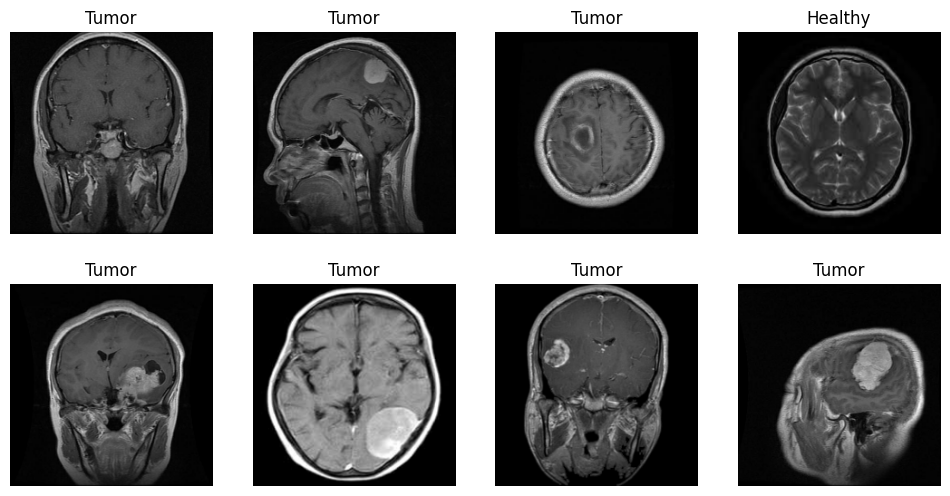

In [ ]:
plt.figure(figsize=(12,6))
for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


In [ ]:
def shuffle_unit(x, out_channels):
    x = tf.keras.layers.Conv2D(out_channels, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.DepthwiseConv2D(3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Conv2D(out_channels, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    return x


In [ ]:
inputs = tf.keras.Input(shape=(224,224,3))
x = tf.keras.layers.Rescaling(1./255)(inputs)

x = tf.keras.layers.Conv2D(24, 3, strides=2, padding="same")(x)
x = tf.keras.layers.MaxPooling2D(3, strides=2, padding="same")(x)

x = shuffle_unit(x, 48)
x = shuffle_unit(x, 96)
x = shuffle_unit(x, 192)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 48)     │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 56, 56, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 56, 56, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 56, 56, 48)     │           432 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 48)     │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 56, 56, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 96)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 56, 56, 96)     │           864 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 96)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 192)    │        18,43

 Total params: 80,690 (315.20 KB)

 Trainable params: 78,674 (307.32 KB)

 Non-trainable params: 2,016 (7.88 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 203s 182ms/step - accuracy: 0.6523 - loss: 0.6313 - val_accuracy: 0.6011 - val_loss: 0.6777
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8112 - loss: 0.4103 - val_accuracy: 0.6184 - val_loss: 0.6516
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8655 - loss: 0.3221 - val_accuracy: 0.9069 - val_loss: 0.2993
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8800 - loss: 0.3083 - val_accuracy: 0.9029 - val_loss: 0.2482
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8817 - loss: 0.2946 - val_accuracy: 0.8989 - val_loss: 0.2923
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8909 - loss: 0.2749 - val_accuracy: 0.9402 - val_loss: 0.1997
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8987 - loss: 0.2547 - val_accuracy: 0.8989 - val_loss: 0.2879
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9066 - loss: 0.2489 - val_a

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step
Accuracy: 0.820855614973262
F1-score: 0.8333333333333334
AUC: 0.9814933187227954


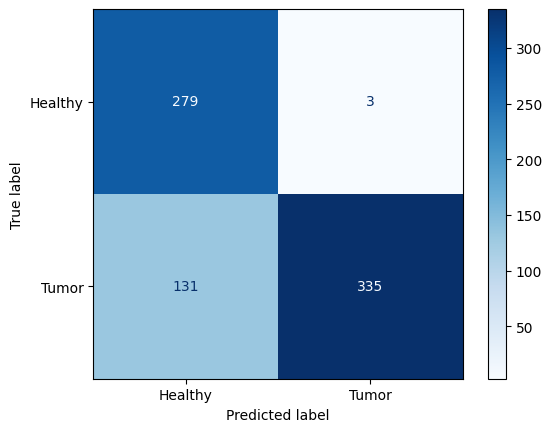

In [ ]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
probs = model.predict(test_ds)
y_pred = np.argmax(probs, axis=1)

acc = accuracy_score(y_true, y_pred)

if NUM_CLASSES == 2:
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, probs[:,1])
else:
    f1 = f1_score(y_true, y_pred, average="macro")
    auc = None

print("Accuracy:", acc)
print("F1-score:", f1)
if auc:
    print("AUC:", auc)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
plt.show()


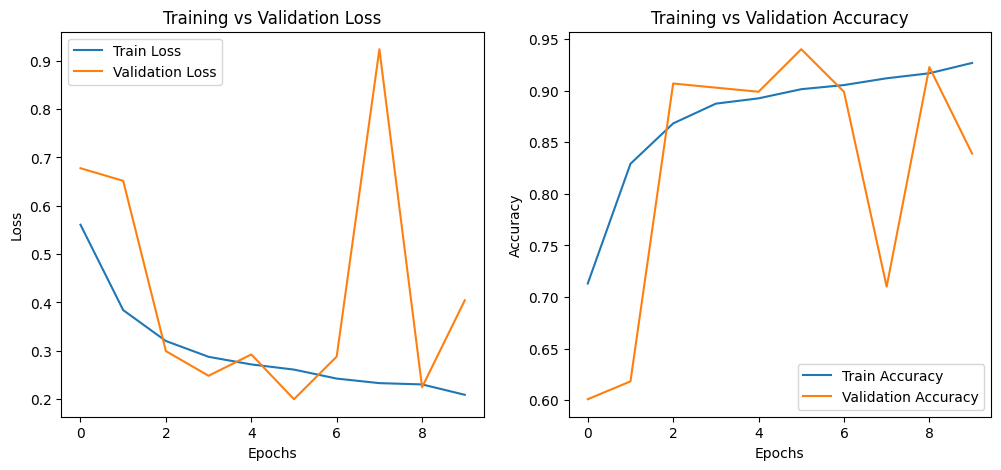

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# -------- LOSS CURVE --------
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")

if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# -------- ACCURACY CURVE --------
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")

if "val_accuracy" in history.history:
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()
